# Electrochemistry: oxygen reduction (ORR)

An electrode potential `U` enters microkinetics exactly where temperature does: it shifts the reaction free energy (computational hydrogen electrode, `+ n F U` per electron) and the forward barrier (Butler-Volmer, `+ β n F U`). Because `discopt.mkm` derives every reverse rate from the equilibrium constant, putting the full shift in the free energy and only the `β` fraction in the barrier makes Butler-Volmer detailed balance automatic. The automatic-differentiation machinery then gives **Tafel slopes** and **transfer coefficients** as the electrochemical analogs of apparent activation energy. We model the 4-electron ORR, draw its CHE free-energy diagram, trace a polarization curve, read off the Tafel slope, and optimize the catalyst descriptor (the volcano).

In [1]:
%matplotlib inline

## The mechanism

Associative acidic ORR, `O2 → OOH* → O* → OH* → H2O`, four proton-coupled electron transfers. The intermediate binding energies come from one descriptor, the OH adsorption free energy `ΔG_OH`, via the standard scaling relations `ΔG_OOH = ΔG_OH + 3.2` eV and `ΔG_O = 2 ΔG_OH`.

In [2]:
import numpy as np, matplotlib.pyplot as plt
import discopt.mkm as mk, discopt.mkm.electrochem as ec
from discopt.mkm.numeric import steady_state_numeric, rate_constants, rates_of_progress

m, reactor = ec.orr_4e(descriptor=0.9)   # ΔG_OH = 0.9 eV (Pt-like)
O2, Hp, H2O = (m._by_name[n] for n in ('O2', 'H\u207a', 'H2O'))
pres = {O2: 1.0, Hp: 1.0, H2O: 1.0}
m

#,reaction,kinetics,type
1,O2 + ∗ + H⁺ ⇌ OOH∗,"A=1e+09, Ea=0.4",reversible
2,OOH∗ + H⁺ ⇌ O∗ + H2O,"A=1e+09, Ea=0.4",reversible
3,O∗ + H⁺ ⇌ OH∗,"A=1e+09, Ea=0.4",reversible
4,OH∗ + H⁺ ⇌ H2O + ∗,"A=1e+09, Ea=0.4",reversible


## CHE free-energy diagram

At `U = 0` every step is downhill; raising the potential lifts each one-electron step by `eU`. The **limiting potential** is the highest `U` at which all steps are still downhill, and the overpotential is `1.23 V − U_L`.

limiting potential U_L = 0.820 V  ->  overpotential = 0.410 V


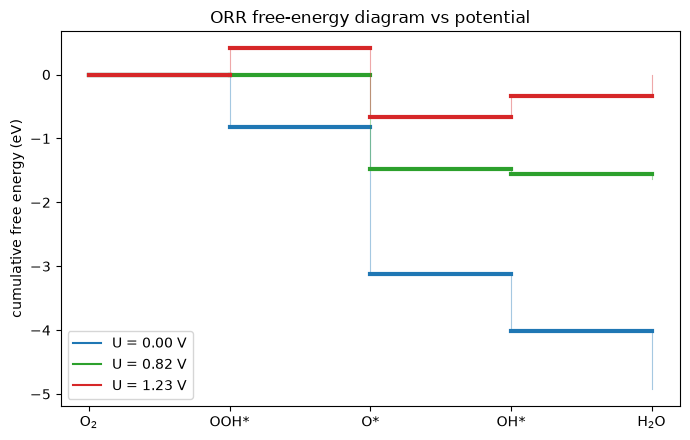

In [3]:
def levels(U):
    _, cum, _ = ec.che_free_energies(m, U=U); return cum
fig, ax = plt.subplots(figsize=(7, 4.5))
for U, c in [(0.0, 'C0'), (ec.limiting_potential(m), 'C2'), (1.23, 'C3')]:
    cum = levels(U)
    for i in range(len(cum)-1):
        ax.plot([i, i+1], [cum[i], cum[i]], c, lw=3)
        ax.plot([i+1, i+1], [cum[i], cum[i+1]], c, lw=0.8, alpha=0.4)
    ax.plot([], [], c, label=f'U = {U:.2f} V')
ax.set_xticks(range(5)); ax.set_xticklabels(['O$_2$', 'OOH*', 'O*', 'OH*', 'H$_2$O'])
ax.set_ylabel('cumulative free energy (eV)'); ax.legend()
ax.set_title('ORR free-energy diagram vs potential')
print(f'limiting potential U_L = {ec.limiting_potential(m):.3f} V  ->  overpotential = {1.23 - ec.limiting_potential(m):.3f} V')
fig.tight_layout()

## Polarization curve and Tafel slope

Sweep the potential and re-solve the steady state at each point; the faradaic current `j = F Σ n_j r_j` turns on below the limiting potential. The Tafel slope and apparent transfer coefficient come straight from the automatic-differentiation sensitivity of the current to `U`.

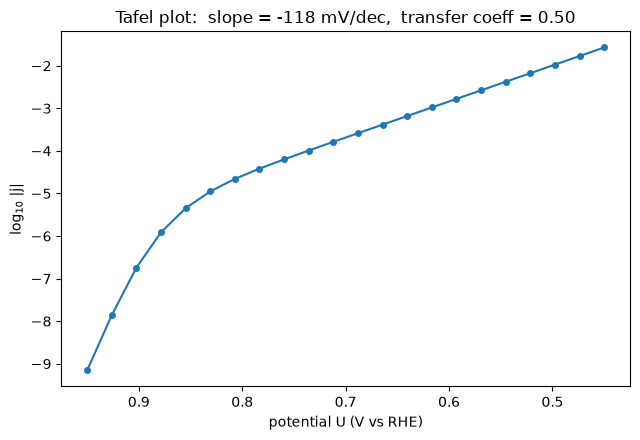

In [4]:
Us = np.linspace(0.95, 0.45, 22); js = []; guess = {a: 0.1 for a in m.adsorbates}
for U in Us:
    m.U = U
    th, fr = steady_state_numeric(m, pres, m.T, theta0=guess); guess = th
    kf, kr = rate_constants(m, m.T, th); rop = rates_of_progress(m, kf, kr, th, fr, pres)
    js.append(m.F * sum(r.n_electrons*rop[r] for r in m.reactions if r.is_electrochemical))
js = np.array(js)

# analytic Tafel diagnostics at a point in the Tafel region
m.U = 0.6
th, _ = steady_state_numeric(m, pres, m.T, theta0=guess)
sol = mk.solve_steady_state(m, mk.DifferentialReactor(pres), theta0=th, active_tol=1e-13)
tafel = ec.tafel_slope(sol); alpha = ec.apparent_transfer_coefficient(sol)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(Us, np.log10(js), 'o-', ms=4)
ax.set_xlabel('potential U (V vs RHE)'); ax.set_ylabel('log$_{10}$ |j|')
ax.set_title(f'Tafel plot:  slope = {tafel*1000:.0f} mV/dec,  transfer coeff = {alpha:.2f}')
ax.invert_xaxis(); fig.tight_layout()

## Which step limits the current?

The degree of rate control of the *current* (the same Campbell DRC, applied to the current expression) says which elementary step the current is most sensitive to at this potential.

In [5]:
drc = ec.degree_of_current_control(sol)
for r, v in sorted(drc.items(), key=lambda kv: -abs(kv[1])):
    print(f'  {v:+.3f}   {r.name}')

  +0.250   OOH* + (H+ + e-) -> O* + H2O
  +0.250   O2 + (H+ + e-) -> OOH*
  +0.250   OH* + (H+ + e-) -> H2O + *
  +0.250   O* + (H+ + e-) -> OH*


## The volcano: optimize the descriptor

Sweeping the descriptor traces the activity volcano (limiting potential vs `ΔG_OH`). discopt finds the peak directly as a small linear program (maximize the limiting potential subject to the scaling relations) without sweeping.

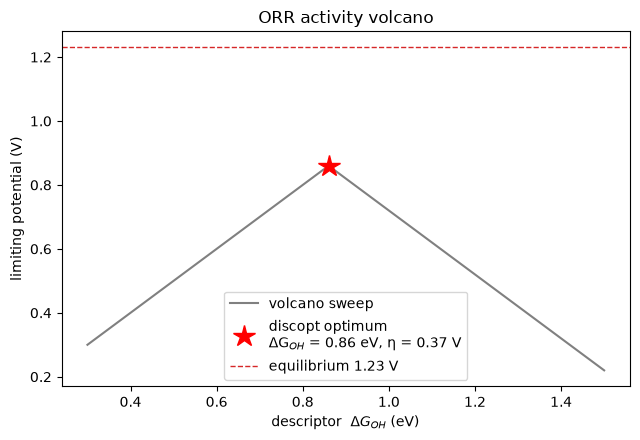

In [6]:
xs = np.linspace(0.3, 1.5, 60)
xv, ul = ec.che_volcano(m, ec.set_orr_descriptor, xs)
ec.set_orr_descriptor(m, 0.9)
opt = ec.optimize_descriptor(ec.ORR_SCALING, ec.ORR_N_ELECTRONS, bounds=(0.3, 1.5), U_eq=ec.ORR_U_EQ)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(xv, ul, '-', color='0.5', label='volcano sweep')
ax.plot(opt['descriptor'], opt['limiting_potential'], 'r*', ms=16,
        label=f"discopt optimum\n\u0394G$_{{OH}}$ = {opt['descriptor']:.2f} eV, \u03b7 = {opt['overpotential']:.2f} V")
ax.axhline(1.23, color='C3', ls='--', lw=1, label='equilibrium 1.23 V')
ax.set_xlabel(r'descriptor  $\Delta G_{OH}$ (eV)'); ax.set_ylabel('limiting potential (V)')
ax.legend(); ax.set_title('ORR activity volcano'); fig.tight_layout()

## Recover the transfer coefficient from the Tafel data

Experimentally `β` is read from the Tafel slope; here we recover it from the (noiseless) polarization curve in the Tafel region, confirming the round-trip.

In [7]:
tafel_region = Us < 0.75
slope = np.polyfit(Us[tafel_region], np.log10(js[tafel_region]), 1)[0]
beta_fit = -slope * 2.303 * m.R * m.T / m.F
print(f'transfer coefficient from the Tafel slope: beta = {beta_fit:.3f}  (model beta = 0.5)')

transfer coefficient from the Tafel slope: beta = 0.501  (model beta = 0.5)


## Takeaways

- The electrode potential is just another global driving variable, like temperature: set `m.U`, mark faradaic steps with `n_electrons` and `beta`, and the CHE free-energy shift and Butler-Volmer barrier shift follow, with detailed balance preserved.
- The **current** is `F Σ n_j r_j`; its potential sensitivity gives the **Tafel slope** (~118 mV/decade for a one-electron rate-determining step) and the **apparent transfer coefficient** (= β here) by the same automatic differentiation that yields apparent activation energy.
- The **CHE free-energy diagram** and **limiting potential** give the thermodynamic overpotential, and discopt's solver finds the **volcano peak** descriptor directly as a linear program.
- Everything reuses the existing steady-state, degree-of-rate-control, and estimation machinery; the electrochemistry is the `discopt.mkm.electrochem` subpackage on top.